# Phần 3 – Bình đẳng giới trong ASEAN: Khoảng cách giữa hai giới ở đâu?

## Động lực:
- Nhóm lựa chọn chủ đề này xuất phát từ những tranh luận, chiến dịch và làn sóng đấu tranh liên quan đến các phong trào nữ quyền trong thời gian gần đây.
- Từ bối cảnh đó, khi có cơ hội tiếp cận và phân tích dữ liệu trong Lab 2, nhóm đặt ra một câu hỏi trọng tâm: “Liệu có tồn tại sự bất công giữa nam và nữ trên thị trường lao động hay không?”
- Tuy nhiên, đây là một vấn đề rộng, chịu ảnh hưởng bởi nhiều yếu tố mà dữ liệu thống kê khó có thể phản ánh đầy đủ. Vì vậy, nhóm thu hẹp phạm vi nghiên cứu thành: “Liệu lao động nữ có đang được định giá đúng trên thị trường lao động hay không?”

## Các mục tiêu phân tích:

1. **Tham gia thị trường lao động:** Nữ tham gia lực lượng lao động ít hơn/nhều hơn nam bao nhiêu? Nước nào có khoảng cách giới nhỏ, nước nào khoảng cách lớn hơn?

2. **Giáo dục bậc đại học:** Ở bậc đại học, tỉ lệ nhập học của nữ so với nam như thế nào? Nước nào đạt/gần đạt “parity” (nữ ≈ nam)?

3. **Chất lượng việc làm và thăng tiến:** Phụ nữ có nhiều trong các vị trí quản lý không, hay chủ yếu tập trung ở việc làm dễ bị tổn thương? Việt Nam đứng ở đâu so với các nước ASEAN có thu nhập cao hơn?

## Vấn đề
- Trình độ học vấn có phản ánh được năng lực làm việc không?
- đem nam vô để xác định xem đây là vấn đề của cả 2 giới tính (vấn đề chung) hay của riêng nữ giới.

-> Tuy nhiên, đây chỉ là một yếu tố trong vô vàng những ẩn số quyết định đáp án cho câu hỏi mà nhóm đặt ra. Tuy không thể trả lời trọn vẹn được câu hỏi ban đầu, nhưng từ 3 mục tiêu phân tích (3 câu hỏi trong quá trình tìm hiểu) chúng ta có thể thấy được một bức tranh ASEAN đang từng bước đi lên, tiên tiến và cởi mở hơn trong thị trường lao động và trong hệ thống giáo dục. Xóa đi những định kiến, những xiền xích vô hình đã níu chân người phụ nữ trong quá khứ.

## Import thư viện và đọc dữ liệu

In [501]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Đường dẫn file dữ liệu (cùng thư mục với notebook)

data_path = "data.csv"

# Đọc file chính chứa các chỉ số WDI đã lọc
# Giá trị thiếu trong WDI thường được ký hiệu là ".." nên cần khai báo na_values
df = pd.read_csv(data_path, na_values=[".."])

print("Kích thước dữ liệu (hàng, cột):", df.shape)
df.head()

Kích thước dữ liệu (hàng, cột): (148, 28)


,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Viet Nam,VNM,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,69.974000,71.493000,70.833000,70.353000,70.098000,70.381000,70.727000,71.138000,71.550000,71.906000,71.731000,71.715000,71.983000,72.906000,73.059000,72.863000,72.530000,72.575000,72.897000,71.511000,69.095000,69.107000,69.878000,69.215000
1,Viet Nam,VNM,"Labor force participation rate, male (% of mal...",SL.TLF.CACT.MA.ZS,77.088000,78.609000,78.296000,78.157000,78.210000,78.453000,78.814000,79.286000,80.008000,80.566000,81.233000,81.466000,81.067000,81.962000,81.945000,82.417000,81.789000,82.197000,82.408000,82.088000,80.025000,78.712000,79.432000,78.201000
2,Viet Nam,VNM,"School enrollment, tertiary, female (% gross)",SE.TER.ENRR.FE,7.787980,7.909690,8.266870,8.612940,NaN,13.112430,16.356440,18.705259,19.384121,20.712139,23.265679,25.413021,13.326013,23.931538,31.758766,29.436537,31.921503,27.444866,NaN,NaN,NaN,41.059099,45.370322,36.077468
3,Viet Nam,VNM,"School enrollment, tertiary, male (% gross)",SE.TER.ENRR.MA,10.674970,10.662680,10.821200,11.197440,NaN,18.590460,17.246309,19.195539,20.739670,22.318171,24.601287,26.327851,38.173576,27.297014,30.911545,30.006648,26.315797,24.494865,NaN,NaN,NaN,42.837902,44.145254,29.637136
4,Viet Nam,VNM,"Vulnerable employment, female (% of female emp...",SL.EMP.VULN.FE.ZS,78.626896,75.656329,76.710296,76.040663,72.989498,72.484119,71.978389,71.472529,70.245955,69.099961,69.624594,69.301928,69.060518,68.942591,68.089468,63.771349,62.247932,61.070384,59.316745,58.813215,58.555162,58.430084,58.415805,57.990049


## Khám phá tổng quan dataset


Trong phần này, chúng ta xem nhanh cấu trúc dữ liệu:

- Các cột định danh: `Country Name`, `Country Code`, `Series Name`, `Series Code`.

- Các cột năm: từ khoảng 2000 đến 2023, dạng `2000 [YR2000]`, ... chứa giá trị của chỉ số theo năm.



Các bước thực hiện:

1. Thống kê số lượng bản ghi và số lượng chỉ số (Series) trong dataset.

2. Kiểm tra dữ liệu thiếu (NA).

*Thông tin chung về dataframe*

In [502]:
print("\nCác cột của dữ liệu:")
print(df.columns.tolist())

print("\nSố nước trong dataset:", df["Country Name"].nunique())
print("Số series (chỉ số) khác nhau:", df["Series Code"].nunique())


Các cột của dữ liệu:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]']

Số nước trong dataset: 13
Số series (chỉ số) khác nhau: 13


*Tỷ lệ giá trị thiếu theo cột*

In [503]:
year_cols = [c for c in df.columns if "[YR" in c]
print("\nSố lượng cột năm:", len(year_cols))

missing_ratio = df[year_cols].isna().mean().sort_values(ascending=False)
print("\nTỷ lệ thiếu trung bình ở các cột năm (top 10):")
print(missing_ratio.head(10))


Số lượng cột năm: 24

Tỷ lệ thiếu trung bình ở các cột năm (top 10):
2005 [YR2005]    0.310811
2004 [YR2004]    0.310811
2003 [YR2003]    0.290541
2001 [YR2001]    0.283784
2006 [YR2006]    0.283784
2002 [YR2002]    0.283784
2000 [YR2000]    0.270270
2008 [YR2008]    0.250000
2009 [YR2009]    0.209459
2007 [YR2007]    0.195946
dtype: float64


## Tiền xử lý
##### **Chuyển dữ liệu sang dạng "dài" (long format)**


Ở dạng gốc, mỗi năm là một cột. Để trực quan hóa và phân tích theo thời gian thuận tiện hơn, ta sẽ chuyển về dạng **long format** với các cột chính:

- `Country Name`, `Country Code`
- `Series Name`, `Series Code`
- `Year` (năm)
- `Value` (giá trị chỉ số)

## == NHẬN XÉT BƯỚC TIỀN XỬ LÝ==

- Chào Phương, bạn hãy tìm hiểu vì sao cần đổi qua dữ liệu long.

*Chuyển sang long format*

In [504]:
#lọc col toàn nan
df = df.dropna(subset=year_cols, how="all").reset_index(drop=True)

id_cols = ["Country Name", "Country Code", "Series Name", "Series Code"]

df_long = df.melt(id_vars=id_cols,
                  value_vars=year_cols,
                  var_name="Year",
                  value_name="Value")

*Rút trích năm từ chuỗi*
###### VD: "2000 [YR2000]" -> 2000

In [505]:
df_long["Year"] = pd.to_numeric(
    df_long["Year"].str.extract(r"(\d{4})", expand=False),
    errors="coerce"
)
df_long = df_long.dropna(subset=["Year"]).copy()
df_long["Year"] = df_long["Year"].astype(int)

*Lọc các nước ASEAN*

In [506]:
asean_countries = ["Viet Nam", "Singapore", "Malaysia", "Thailand", "Indonesia", "Philippines", "Brunei Darussalam", "Cambodia", "Lao PDR", "Myanmar", "Timor-Leste"]
df_asean = df_long[df_long["Country Name"].isin(asean_countries)].copy()

print("Kích thước dữ liệu long (ASEAN):", df_asean.shape)
df_asean.head()

Kích thước dữ liệu long (ASEAN): (3432, 6)


,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Viet Nam,VNM,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,2000,69.974000
1,Viet Nam,VNM,"Labor force participation rate, male (% of mal...",SL.TLF.CACT.MA.ZS,2000,77.088000
2,Viet Nam,VNM,"School enrollment, tertiary, female (% gross)",SE.TER.ENRR.FE,2000,7.787980
3,Viet Nam,VNM,"School enrollment, tertiary, male (% gross)",SE.TER.ENRR.MA,2000,10.674970
4,Viet Nam,VNM,"Vulnerable employment, female (% of female emp...",SL.EMP.VULN.FE.ZS,2000,78.626896


## 5. **Câu hỏi 1**
### *Sự tham gia của nữ trong thị trường lao động tại Việt Nam và các quốc gia trong khu vực diễn ra như thế nào? Có tồn tại sự chênh lệch đáng kể so với nam giới, hoặc có xu hướng thay đổi nào đáng chú ý trong giai đoạn 2000–2023 không?*


Chỉ số (metrics) sử dụng:

- `SL.TLF.CACT.FE.ZS`: Labor force participation rate, female (% of female population 15+).

- `SL.TLF.CACT.MA.ZS`: Labor force participation rate, male (% of male population 15+).

Động lực:
- Quan niệm “đàn ông xây nhà, đàn bà xây tổ ấm” đã tồn tại từ lâu trong xã hội châu Á, đặc biệt là khu vực Đông Nam Á. Quan niệm này xuất phát một phần từ văn hóa, phong tục, và phần nào chịu ảnh hưởng của Nho giáo qua nhiều thế hệ.
- Do đó, trong bối cảnh xã hội hiện đại và đổi mới (2000–2023), nhóm muốn kiểm chứng liệu quan niệm này còn tồn tại hay không, và nếu có thì ở mức độ nào. Bước đầu tiên là phân tích các chỉ số liên quan đến sự tham gia thị trường lao động.
- Được tham gia vào thị trường lao động là một khẳng định gián tiếp cho việc được tự chủ tài chính, có khả năng tự chăm lo cho đời sống của bản thân và đóng góp ở mặt tài chính cho gia đình. Đây cũng là một yếu tố quan trọng trong việc đánh giá mức độ bình đẳng giới.

Mục tiêu:

- Phân tích xu hướng thay đổi tỷ lệ tham gia lực lượng lao động của nữ theo thời gian tại từng quốc gia.
- Đo lường khoảng cách giữa nam và nữ trong việc tham gia thị trường lao động tại thời điểm gần nhất trong bộ dữ liệu (năm 2023), từ đó so sánh giữa các quốc gia.

Câu hỏi mở rộng:
- Yếu tố dân số có ảnh hưởng như thế nào đến các kết quả quan sát được?
- Cần phân tích sâu hơn về xu hướng tham gia của nam giới để có cái nhìn toàn diện hơn về khoảng cách giới.

*Chỉ số (metrics) sử dụng*

Năm tham chiếu LFPR: 2023


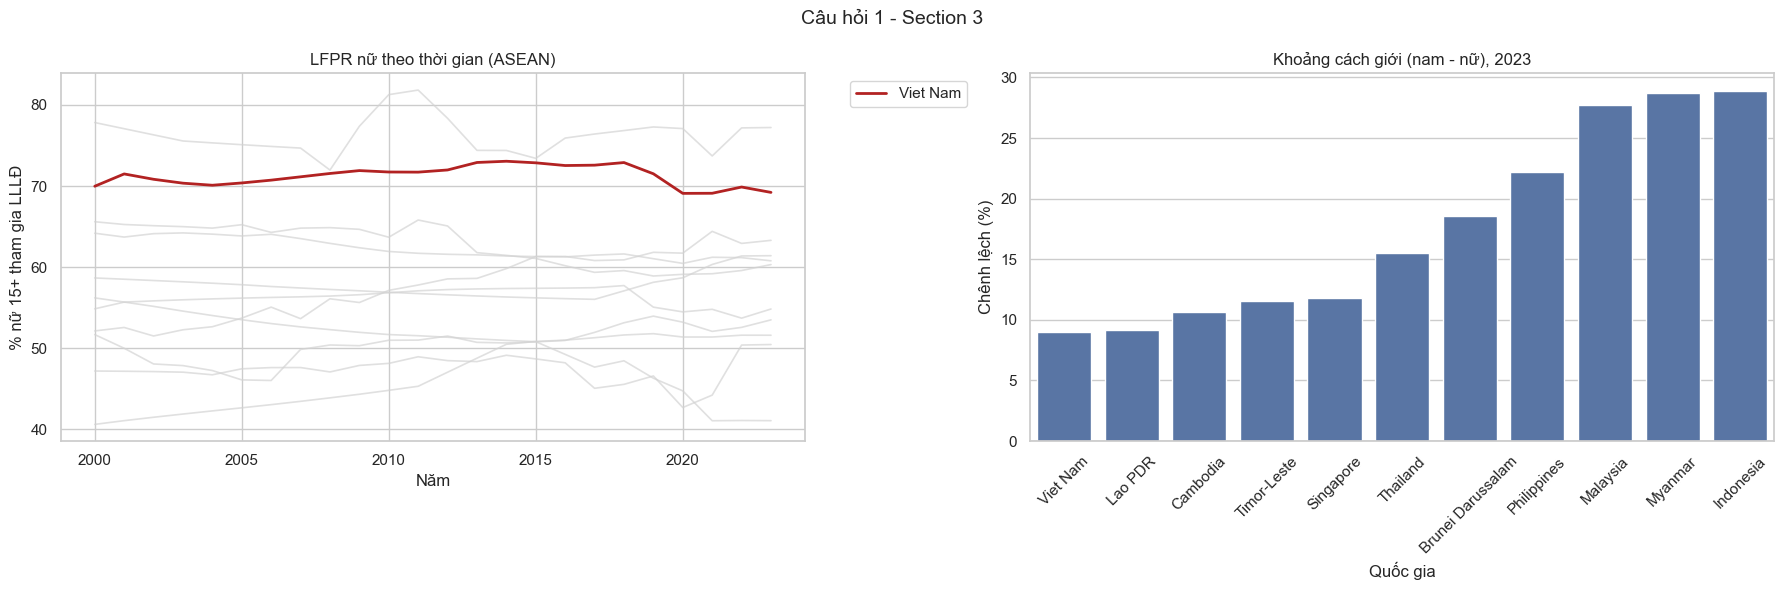

In [507]:
question1_section3 = {
    "female": "SL.TLF.CACT.FE.ZS",
    "male": "SL.TLF.CACT.MA.ZS",
}

df_q1_sect3 = df_asean[df_asean["Series Code"].isin(question1_section3.values())].copy()

lfpr_pivot = df_q1_sect3.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Code",
    values="Value"
)

lfpr_pivot = lfpr_pivot.rename(columns={
    question1_section3["female"]: "lfpr_female",
    question1_section3["male"]: "lfpr_male",
}).reset_index()

lfpr_pivot["gap_male_minus_female"] = lfpr_pivot["lfpr_male"] - lfpr_pivot["lfpr_female"]

#*Chọn năm tham chiếu cho so sánh*

year_ref_lfpr = 2023
if year_ref_lfpr not in lfpr_pivot["Year"].unique():
    year_ref_lfpr = int(lfpr_pivot["Year"].max())
print("Năm tham chiếu LFPR:", year_ref_lfpr)

latest_lfpr = lfpr_pivot[lfpr_pivot["Year"] == year_ref_lfpr].dropna(subset=["lfpr_female", "lfpr_male"])
latest_lfpr = latest_lfpr.sort_values("gap_male_minus_female")

#Biểu đồ đường LFPR của nữ theo thời gian cho từng nước
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# =======================
# (1) Line chart: LFPR nữ theo thời gian (ASEAN)
# =======================
palette = sns.color_palette("tab20", n_colors=len(asean_countries))

for i, country in enumerate(asean_countries):
    subset = lfpr_pivot[lfpr_pivot["Country Name"] == country]
    if subset.empty:
        continue

    if country == 'Viet Nam':
        axes[0].plot(
            subset["Year"], subset["lfpr_female"],
            label=country, color="firebrick", linewidth=2
        )
    else:
        axes[0].plot(
            subset["Year"], subset["lfpr_female"],
            color="lightgray", linewidth=1.2, alpha=0.7
        )

axes[0].set_title("LFPR nữ theo thời gian (ASEAN)")
axes[0].set_xlabel("Năm")
axes[0].set_ylabel("% nữ 15+ tham gia LLLĐ")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left")


# =======================
# (2) Bar chart: gender gap
# =======================
sns.barplot(
    data=latest_lfpr,
    x="Country Name",
    y="gap_male_minus_female",
    ax=axes[1]
)

axes[1].set_title(f"Khoảng cách giới (nam - nữ), {year_ref_lfpr}")
axes[1].set_xlabel("Quốc gia")
axes[1].set_ylabel("Chênh lệch (%)")
axes[1].tick_params(axis='x', rotation=45)

axes[1].axhline(0, color="black", linewidth=0.8)
fig.suptitle("Câu hỏi 1 - Section 3", fontsize=14)


# =======================
# Layout chung
# =======================
plt.tight_layout()
plt.show()

Chart này cho ra những xu hướng rất thú vị, từ đó cũng nhìn ra được những câu chuyện, những biến chuyển của ASEAN trong giai đoạn.  
Em sẽ nhận xét theo thứ tự của Legend:  


**Nhận xét**
- Bất ngờ với Cambodia dẫn đầu trong tỷ lệ lao động nữ.
- Việt Nam xếp thứ 2, duy trì ổn định ở mức ~70% trong cả giai đoạn. Tuy có xuất hiện những biến động (đường biểu đồ dốc xuống khá nhanh nửa cuối giai đoạn 2015-2020). Nhưng so với khu vực thì không đáng kể.
- Singapore, Malaysia tăng trưởng khá đều đặn qua từng năm.
- Philippines biến động nhiều. Đặc biệt ghi nhận là giảm nhanh ở giai đoạn 2015-2020 và tăng mạnh vào giai đoạn 2020-2023.
- Trái với sự tăng trưởng của các nước khác, tỉ lệ lao động nữ của Myanmar lại giảm dần và bắt đầu giảm mạnh về mức 40% từ năm 2015.
- Còn lại các nước có sự biến động nhưng không đáng kể.

**Những điểm cần làm rõ**
- Chuyện gì đã xảy ra vào giai đoạn 2015-2020?
- Tại sao Myanmar lại đi ngược xu hướng phát triển chung của khu vực?

***Biểu đồ cột khoảng cách giới (nam - nữ) cho năm 2023***

**Nhận xét**
- 

**Câu hỏi**
- Tỉ lệ này còn phụ thuộc vào những yếu tố nào? (dân số,..)

## 6. **Câu hỏi 2**
### *Giáo dục đóng vai trò như thế nào đối với cả hai giới? Có tồn tại sự chênh lệch về trình độ học vấn giữa nam và nữ hay không?*



Chỉ số (metrics) sử dụng:

- `SE.TER.ENRR.FE`: School enrollment, tertiary, female (% gross).
- `SE.TER.ENRR.MA`: School enrollment, tertiary, male (% gross).

Động lực:
- Sau khi phân tích sự tham gia vào thị trường lao động của hai giới, bước tiếp theo là đi sâu vào các yếu tố nền tảng có thể ảnh hưởng đến sự tham gia này, trong đó giáo dục là yếu tố quan trọng.
- Thị trường lao động có nhiều phân tầng và thường gắn chặt với trình độ học vấn, vì vậy cần xem xét vị trí của nữ giới trong hệ thống giáo dục tại các quốc gia ASEAN.
- Từ đó, đặt ra câu hỏi liệu trình độ học vấn có đang trở thành rào cản đối với sự tham gia của phụ nữ vào thị trường lao động hay không.

Mục tiêu: (khoảng năm)
- Phân tích tỷ lệ hoàn thành bậc trung học của nam và nữ theo thời gian.
- Theo dõi xu hướng tỷ lệ nhập học bậc đại học của hai giới theo thời gian để đánh giá mức độ chênh lệch.

Năm gần nhất có dữ liệu tertiary enrollment: 2023


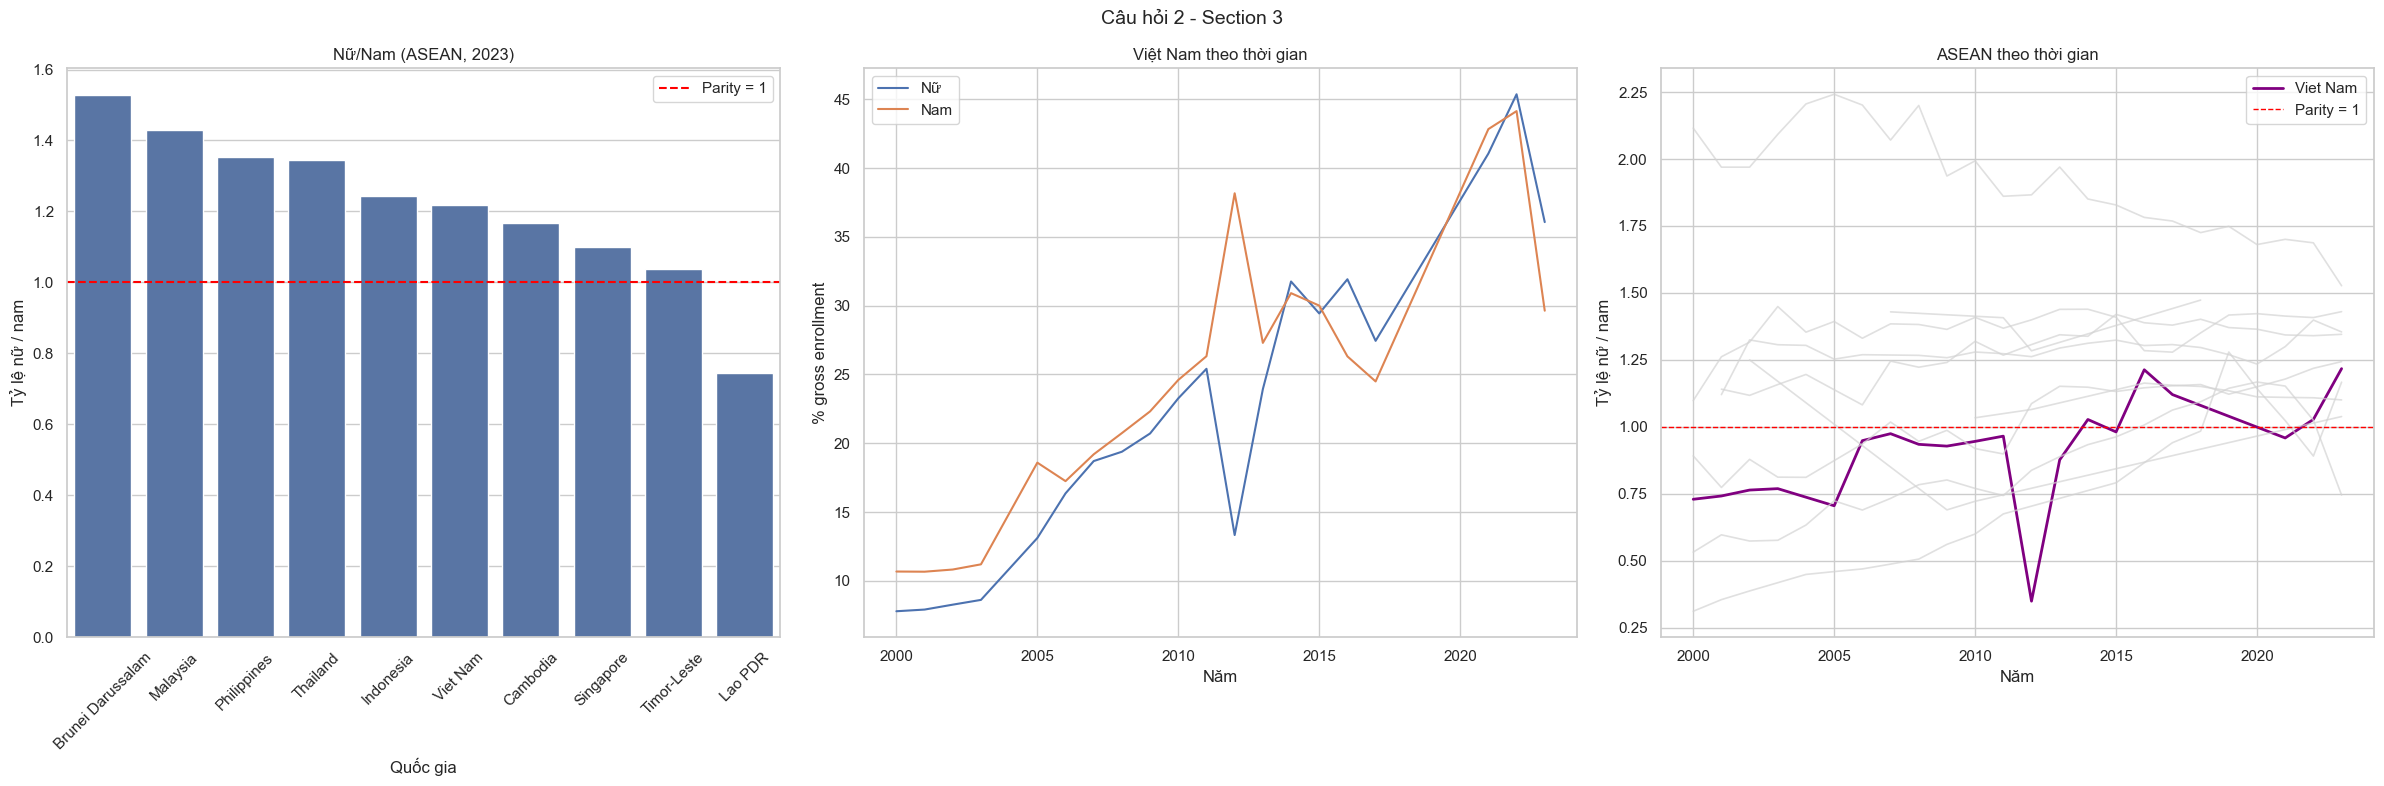

In [508]:
question2_section3 = {
    "female": "SE.TER.ENRR.FE",
    "male": "SE.TER.ENRR.MA",
}

#tạo df
df_q2_sect3 = df_asean[df_asean["Series Code"].isin(question2_section3.values())].copy()

ter_pivot = df_q2_sect3.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Code",
    values="Value"
)

ter_pivot = ter_pivot.rename(columns={
    question2_section3["female"]: "ter_female",
    question2_section3["male"]: "ter_male",
}).reset_index()

# thay thành khoảng năm gần nhất có dữ liệu

ter_pivot["female_to_male"] = ter_pivot["ter_female"] / ter_pivot["ter_male"]

# Năm gần nhất có dữ liệu tertiary
#latest_year_ter = int(ter_pivot["Year"].max())
latest_year_ter = 2023
print("Năm gần nhất có dữ liệu tertiary enrollment:", latest_year_ter)

latest_ter = ter_pivot[ter_pivot["Year"] == latest_year_ter].dropna(subset=["ter_female", "ter_male"])
latest_ter.sort_values("female_to_male", ascending=False, inplace=True)


#Biểu đồ parity nữ/nam theo quốc gia cho năm 2023
# Tạo figure gồm 3 subplot (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# =======================
# (1) Bar chart: parity 2023
# =======================
sns.barplot(
    data=latest_ter,
    x="Country Name",
    y="female_to_male",
    ax=axes[0]
)

axes[0].set_title(f"Nữ/Nam (ASEAN, {latest_year_ter})")
axes[0].set_xlabel("Quốc gia")
axes[0].set_ylabel("Tỷ lệ nữ / nam")
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(1, color="red", linestyle="--", label="Parity = 1")
axes[0].legend()


# =======================
# (2) Line chart: Việt Nam theo thời gian
# =======================
vn_ter = ter_pivot[
    ter_pivot["Country Name"] == "Viet Nam"
].dropna(subset=["ter_female", "ter_male"])

sns.lineplot(data=vn_ter, x="Year", y="ter_female", label="Nữ", ax=axes[1])
sns.lineplot(data=vn_ter, x="Year", y="ter_male", label="Nam", ax=axes[1])

axes[1].set_title("Việt Nam theo thời gian")
axes[1].set_xlabel("Năm")
axes[1].set_ylabel("% gross enrollment")
axes[1].legend()


# =======================
# (3) Line chart: ASEAN female/male ratio
# =======================
for country in asean_countries:
    subset = ter_pivot[
        ter_pivot["Country Name"] == country
    ].dropna(subset=["female_to_male"])
    
    if subset.empty:
        continue
    
    if country == 'Viet Nam':
        axes[2].plot(
            subset["Year"], subset["female_to_male"],
            label=country, color="purple", linewidth=2
        )
    else:
        axes[2].plot(
            subset["Year"], subset["female_to_male"],
            color="lightgray", linewidth=1.2, alpha=0.7
        )

axes[2].axhline(1, color="red", linestyle="--", linewidth=1, label="Parity = 1")
axes[2].set_title("ASEAN theo thời gian")
axes[2].set_xlabel("Năm")
axes[2].set_ylabel("Tỷ lệ nữ / nam")
axes[2].legend()

# =======================
# Layout chung
# =======================
fig.suptitle("Câu hỏi 2 - Section 3", fontsize=14)
plt.tight_layout()
plt.show()


## **Câu hỏi 3**
### *Chất lượng việc làm và cơ hội thăng tiến của phụ nữ trong ASEAN phản ánh điều gì về bất bình đẳng giới? Liệu phụ nữ có đang bị “mắc kẹt” ở những vị trí dễ tổn thương, hay đã có cơ hội vươn lên trong nền kinh tế?*



Chỉ số (metrics) sử dụng:

- `SL.UEM.NEET.FE.ZS`, `SL.UEM.NEET.MA.ZS`: Share of youth not in education, employment or training (NEET), nữ/nam.

- `SL.EMP.SMGT.FE.ZS`: Female share of employment in senior and middle management (%).

- `NY.GDP.PCAP.KD`: GDP per capita (constant 2015 US$).

Động lực:
- Sau khi xem xét mức độ tham gia thị trường lao động và yếu tố giáo dục, bước tiếp theo là đánh giá chất lượng việc làm và cơ hội phát triển nghề nghiệp của phụ nữ.
- Không chỉ dừng lại ở việc “có việc làm”, điều quan trọng là phụ nữ đang làm việc ở đâu trong chuỗi giá trị lao động: ở các vị trí ổn định, có cơ hội thăng tiến, hay chủ yếu ở những công việc dễ bị tổn thương?
- Đồng thời, cần xem xét liệu sự phát triển kinh tế của một quốc gia có đi kèm với việc cải thiện vị thế của phụ nữ trong thị trường lao động hay không.



Mục tiêu:

- So sánh tỷ lệ NEET giữa nữ và nam để đánh giá liệu phụ nữ trẻ có đối mặt với nguy cơ “không học – không làm” cao hơn hay không.
- Phân tích tỷ lệ phụ nữ trong các vị trí quản lý và đặt trong tương quan với mức GDP bình quân đầu người.
- Từ đó, rút ra nhận định về mô hình phát triển của các quốc gia ASEAN: phụ nữ chỉ tham gia lao động ở các vị trí thấp, hay thực sự có cơ hội thăng tiến và nắm giữ vai trò quan trọng.

In [509]:
year_ref = 2023
if year_ref not in df_asean["Year"].unique():
    year_ref = int(df_asean["Year"].max())
print("Năm tham chiếu:", year_ref)

Năm tham chiếu: 2023


*Chỉ số (metrics) sử dụng*

In [510]:
question3_section3 = {
    "neet_female": "SL.UEM.NEET.FE.ZS",
    "neet_male": "SL.UEM.NEET.MA.ZS",
}

mgmt_code = "SL.EMP.SMGT.FE.ZS"  # nữ trong vị trí quản lý
parl_code = "SG.GEN.PARL.ZS"  # Tỷ lệ nữ trong quốc hội
gdp_pc_code = "NY.GDP.PCAP.KD"   # GDP per capita (constant 2015 US$)

subset = df_asean[df_asean["Year"] == year_ref].copy()
neet = subset[subset["Series Code"].isin(question3_section3.values())]

neet_pivot = neet.pivot_table(
    index="Country Name",
    columns="Series Code",
    values="Value"
)

neet_pivot = neet_pivot.rename(columns={
    question3_section3["neet_female"]: "neet_female",
    question3_section3["neet_male"]: "neet_male",
})

mgmt = subset[subset["Series Code"] == mgmt_code].set_index("Country Name")["Value"].rename("female_mgmt")
gdp_pc = subset[subset["Series Code"] == gdp_pc_code].set_index("Country Name")["Value"].rename("gdp_per_capita")
parl = subset[subset["Series Code"] == parl_code].set_index("Country Name")["Value"].rename("female_parl")

# Gộp tất cả vào một bảng
summary = neet_pivot.join(mgmt, how="outer").join(gdp_pc, how="outer").join(parl, how="outer")

# Chênh lệch NEET nữ - nam
summary["neet_gap_female_minus_male"] = summary["neet_female"] - summary["neet_male"]

summary

,neet_female,neet_male,female_mgmt,gdp_per_capita,female_parl,neet_gap_female_minus_male
Country Name,,,,,,
Brunei Darussalam,18.913,14.356,38.990,28645.964540,11.764706,4.557
Cambodia,8.342,4.333,23.571,2085.057485,13.600000,4.009
Indonesia,26.323,16.694,24.823,4192.651679,21.565217,9.629
Lao PDR,NaN,NaN,NaN,2648.887266,21.951220,NaN
Malaysia,NaN,NaN,NaN,11445.392528,13.513514,NaN
Myanmar,NaN,NaN,NaN,1177.766496,NaN,NaN
Philippines,15.554,9.326,43.164,3744.697638,27.331190,6.228
Singapore,5.912,7.528,39.807,66167.359630,29.126214,-1.616
Thailand,15.546,9.396,34.694,6408.414326,18.837675,6.150


***Biểu đồ NEET nữ vs nam theo quốc gia***

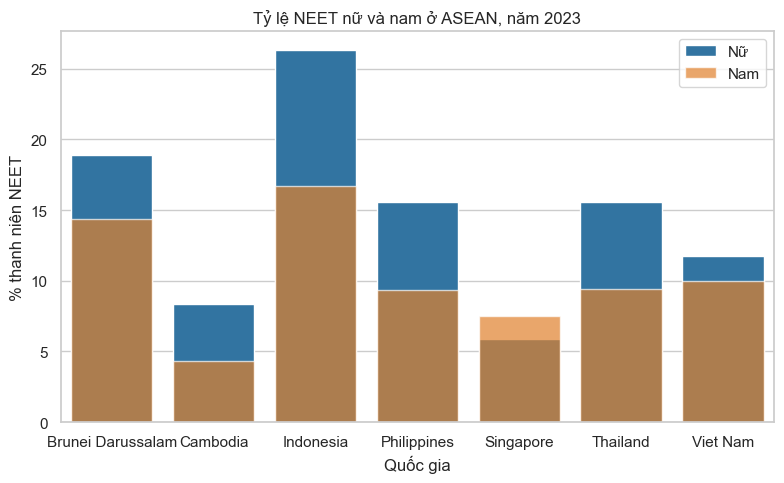

In [511]:
neet_plot = summary.dropna(subset=["neet_female", "neet_male"]).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=neet_plot,
    x="Country Name",
    y="neet_female",
    color="tab:blue",
    label="Nữ"
)

sns.barplot(
    data=neet_plot,
    x="Country Name",
    y="neet_male",
    color="tab:orange",
    label="Nam",
    alpha=0.7
)

plt.title(f"Tỷ lệ NEET nữ và nam ở ASEAN, năm {year_ref}")
plt.xlabel("Quốc gia")
plt.ylabel("% thanh niên NEET")
plt.legend()
plt.tight_layout()

plt.show()

*Biểu đồ GDP bình quân đầu người vs tỷ lệ nữ trong vị trí quản lý*

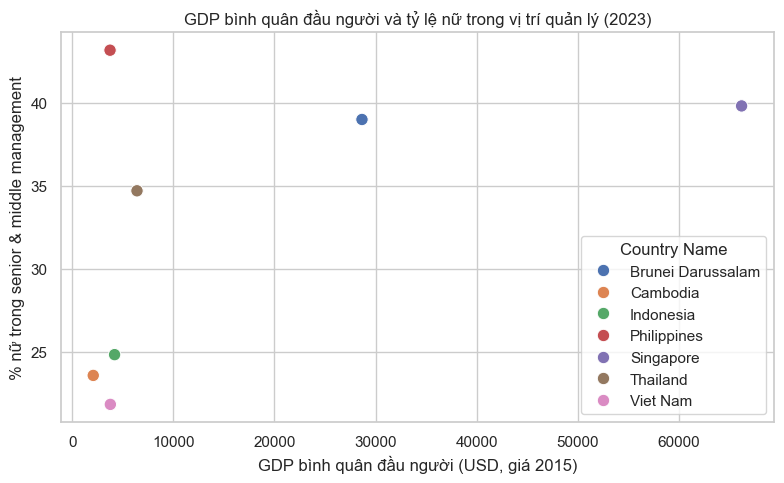

In [512]:
mgmt_plot = summary.dropna(subset=["female_mgmt", "gdp_per_capita"]).reset_index()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=mgmt_plot,
    x="gdp_per_capita",
    y="female_mgmt",
    hue="Country Name",
    s=80
)

plt.title(f"GDP bình quân đầu người và tỷ lệ nữ trong vị trí quản lý ({year_ref})")
plt.xlabel("GDP bình quân đầu người (USD, giá 2015)")
plt.ylabel("% nữ trong senior & middle management")
plt.tight_layout()

plt.show()

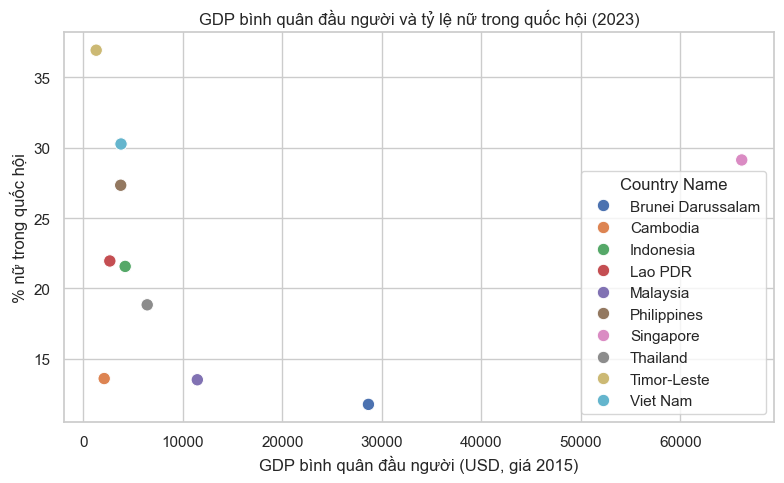

In [513]:
parl_plot = summary.dropna(subset=["female_parl", "gdp_per_capita"]).reset_index()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=parl_plot,
    x="gdp_per_capita",
    y="female_parl",
    hue="Country Name",
    s=80
)
plt.title(f"GDP bình quân đầu người và tỷ lệ nữ trong quốc hội ({year_ref})")
plt.xlabel("GDP bình quân đầu người (USD, giá 2015)")
plt.ylabel("% nữ trong quốc hội")
plt.tight_layout()

plt.show()